Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000
Selected timestep water depth: 2017-08-26T02:30:00.000000000


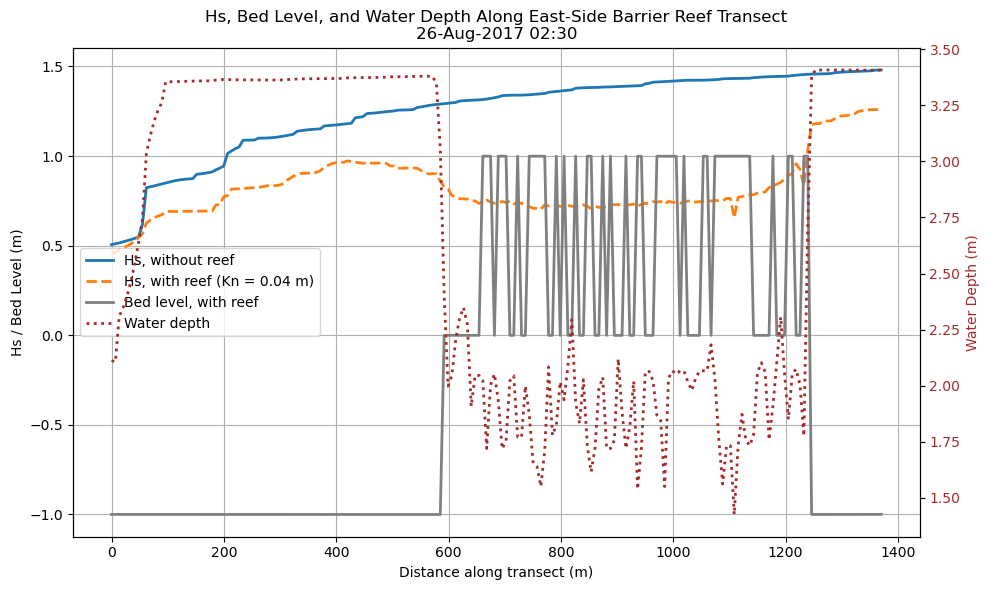

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition: west-side fringing reef, Kn = 0.04 m
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# With reef bathymetry mesh
mesh_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\updated_bathymetry_east_side.mesh"

# Without reef bathymetry DFSU
bathy_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736598, 3177013
x2, y2 = 735385, 3176376

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from mesh
# =========================
def extract_bed_from_mesh(mesh_file):
    geom = mikeio.Mesh(mesh_file).geometry

    # In MIKE mesh, node z is usually bed level/elevation
    node_x = geom.node_coordinates[:, 0]
    node_y = geom.node_coordinates[:, 1]
    node_z = geom.node_coordinates[:, 2]

    # Use nearest node interpolation for bed level
    from scipy.spatial import cKDTree

    tree = cKDTree(np.column_stack([node_x, node_y]))
    _, idx = tree.query(coords)

    bed_profile = node_z[idx]

    return bed_profile


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu_bathy(dfsu_file):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, item in enumerate(dfs.items):
        print(i, item.name)

    # Change item name below if needed after checking printed item names
    ds = dfs.read(items=[0])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

# Hs profiles
hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Sign. Wave Height",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Sign. Wave Height",
    target_time
)

# Water depth profile from reef simulation
water_depth_reef, time_depth = extract_dfsu_profile(
    dfsu_reef,
    "Water depth",
    target_time
)

# Bed levels
bed_reef = extract_bed_from_mesh(mesh_reef)

# Use this if you also want to compare existing bathymetry
# bed_no_reef = extract_bed_from_dfsu_bathy(bathy_no_reef)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)
print("Selected timestep water depth:", time_depth)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Hs and bed level
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Hs, without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with reef (Kn = 0.04 m)"
)

ax1.plot(
    distance,
    bed_reef,
    linewidth=2,
    color="grey",
    label="Bed level, with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Hs / Bed Level (m)")
ax1.grid(True)

# Secondary y-axis: water depth
ax2 = ax1.twinx()

ax2.plot(
    distance,
    water_depth_reef,
    linewidth=2,
    linestyle=":",
    color="brown",
    label="Water depth"
)

ax2.set_ylabel("Water Depth (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Hs, Bed Level, and Water Depth Along East-Side Barrier Reef Transect\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000
Selected timestep water depth with reef: 2017-08-26T02:30:00.000000000


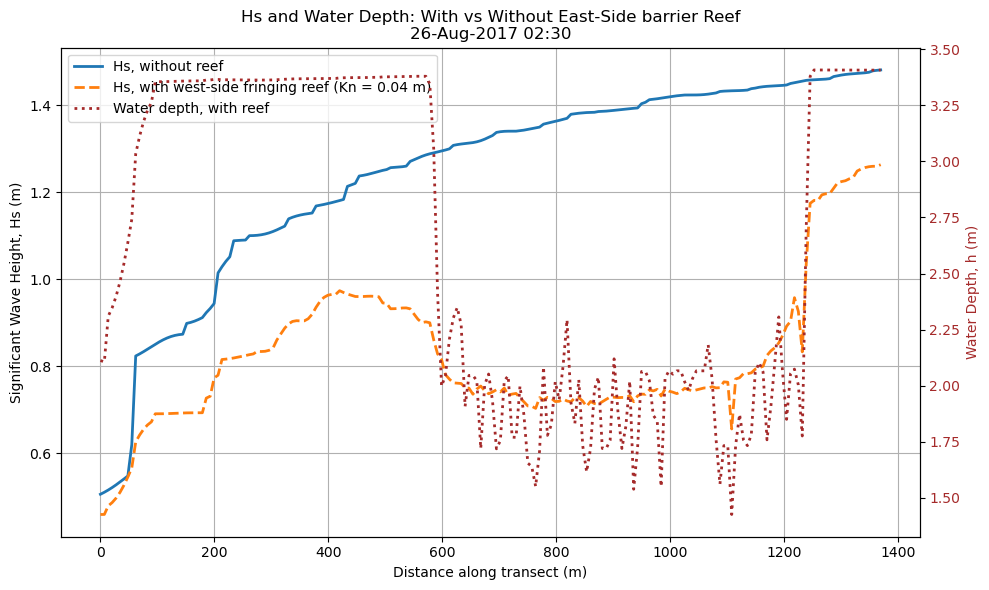

In [3]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_with_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

dfsu_without_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Transect endpoints
x1, y1 = 736598, 3177013
x2, y2 = 735385, 3176376

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_with_reef, time_with_reef = extract_profile(
    dfsu_with_reef,
    "Sign. Wave Height"
)

hs_without_reef, time_without_reef = extract_profile(
    dfsu_without_reef,
    "Sign. Wave Height"
)

# Extract only with-reef water depth
depth_with_reef, time_depth_with = extract_profile(
    dfsu_with_reef,
    "Water depth"
)

print("Selected timestep with reef:", time_with_reef)
print("Selected timestep without reef:", time_without_reef)
print("Selected timestep water depth with reef:", time_depth_with)

# Plot Hs and with-reef water depth
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Significant wave height
ax1.plot(
    distance,
    hs_without_reef,
    linewidth=2,
    label="Hs, without reef"
)

ax1.plot(
    distance,
    hs_with_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with west-side fringing reef (Kn = 0.04 m)"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant Wave Height, Hs (m)")
ax1.grid(True)

# Secondary axis: Water depth with reef only
ax2 = ax1.twinx()

ax2.plot(
    distance,
    depth_with_reef,
    linewidth=2,
    color="brown",
    linestyle=":",
    label="Water depth, with reef"
)

ax2.set_ylabel("Water Depth, h (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Hs and Water Depth: With vs Without East-Side barrier Reef\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


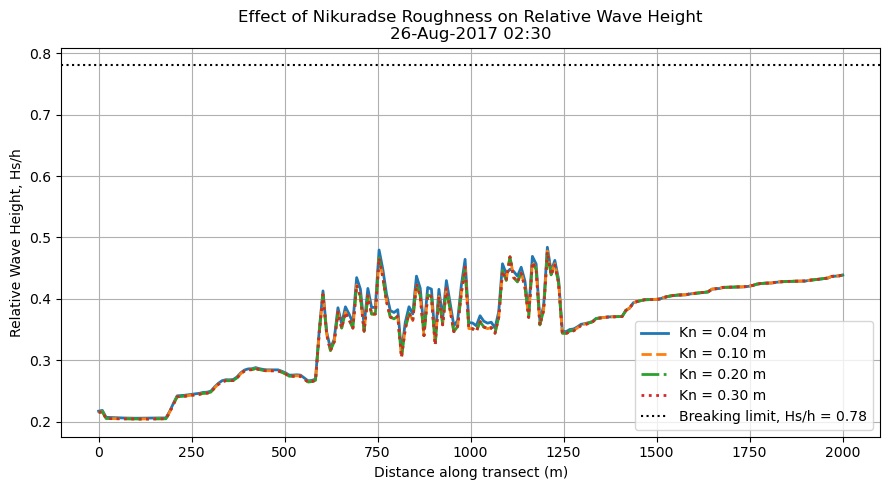

In [4]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.1m.sw - Result Files\east_side_reef_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.2m.sw - Result Files\east_side_reef_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.3m.sw - Result Files\east_side_reef_0.3m.dfsu"

# Transect endpoints
x1, y1 = 736598, 3177013
x2, y2 = 734827, 3176083

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


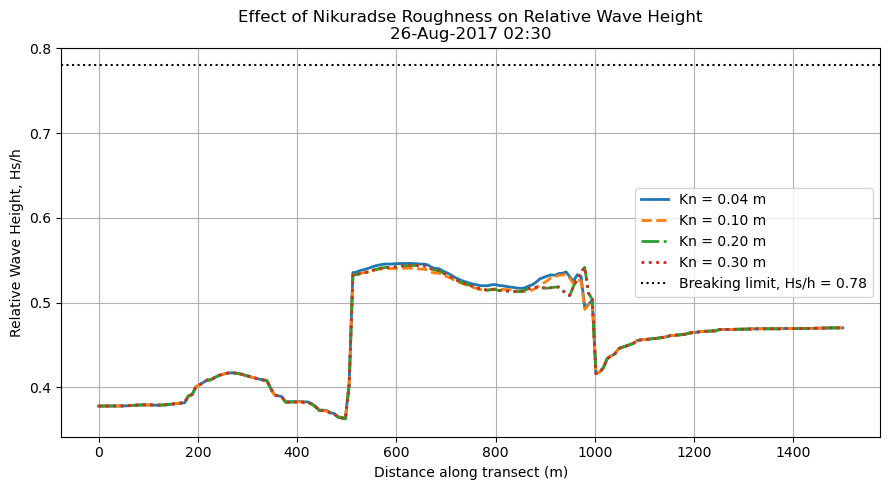

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v2.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v2.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


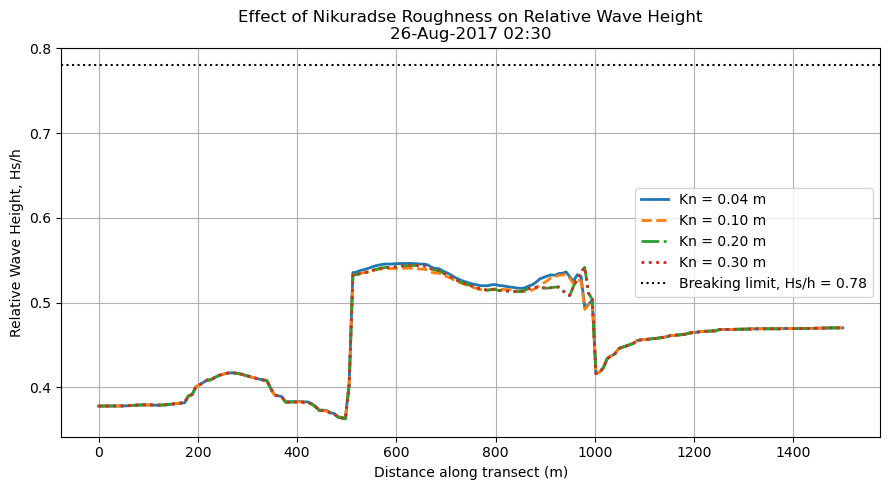

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v2.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v2.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


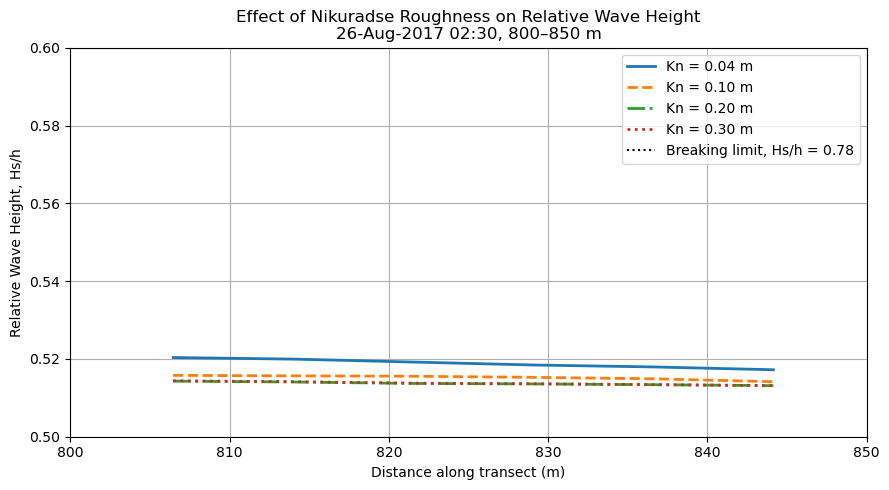

In [3]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v2.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v2.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Select only 800–850 m
mask = (distance >= 800) & (distance <= 850)

# Plot only 800–850 m
plt.figure(figsize=(9, 5))

plt.plot(distance[mask], ratio_004[mask], linewidth=2, label="Kn = 0.04 m")
plt.plot(distance[mask], ratio_01[mask],  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance[mask], ratio_02[mask],  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance[mask], ratio_03[mask],  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30, 800–850 m")

plt.xlim(800, 850)
plt.ylim(0.5,0.6)
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


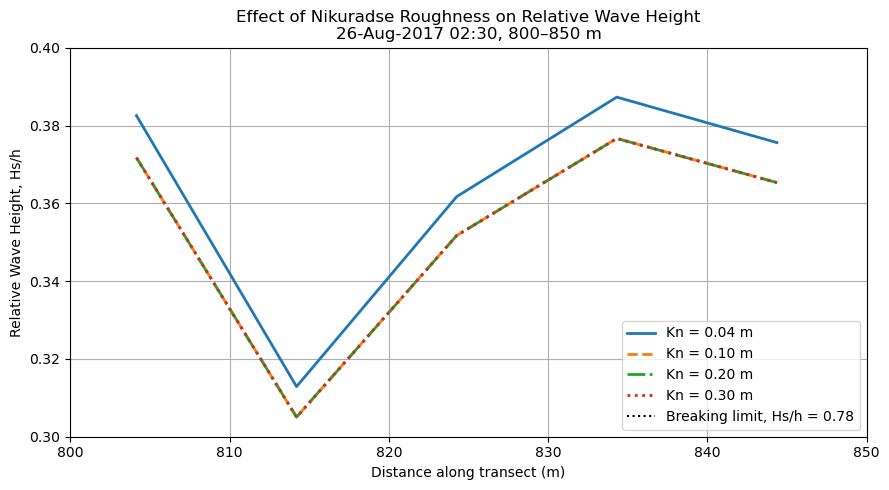

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.1m.sw - Result Files\east_side_reef_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.2m.sw - Result Files\east_side_reef_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.3m.sw - Result Files\east_side_reef_0.3m.dfsu"

# Transect endpoints
x1, y1 = 736598, 3177013
x2, y2 = 734827, 3176083

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Select only 800–850 m
mask = (distance >= 800) & (distance <= 850)

# Plot only 800–850 m
plt.figure(figsize=(9, 5))

plt.plot(distance[mask], ratio_004[mask], linewidth=2, label="Kn = 0.04 m")
plt.plot(distance[mask], ratio_01[mask],  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance[mask], ratio_02[mask],  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance[mask], ratio_03[mask],  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30, 800–850 m")

plt.xlim(800, 850)
plt.ylim(0.3,0.4)
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


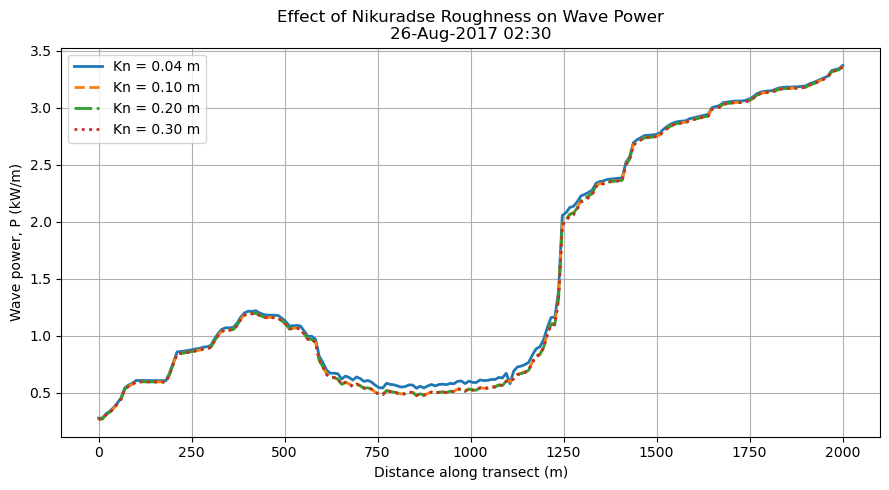

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.1m.sw - Result Files\east_side_reef_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.2m.sw - Result Files\east_side_reef_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\east_side_barrier_reef_roughness_0.3m.sw - Result Files\east_side_reef_0.3m.dfsu"

# Transect endpoints
x1, y1 = 736598, 3177013
x2, y2 = 734827, 3176083

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


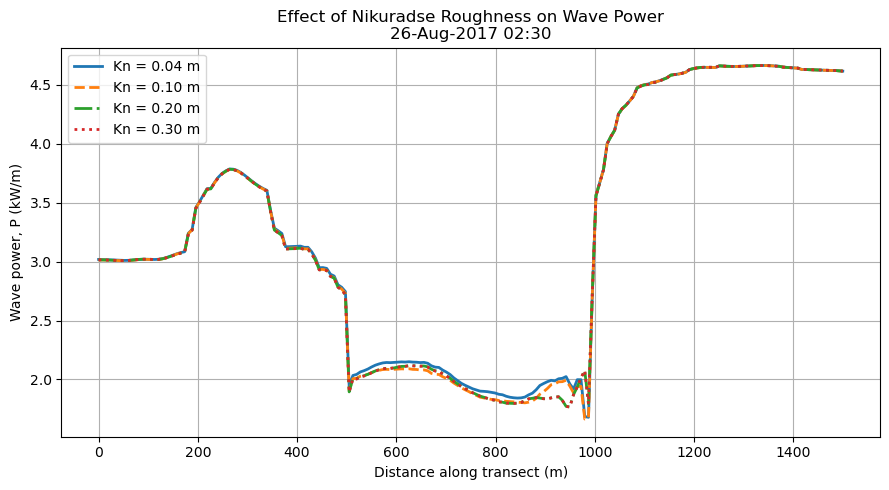

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v2.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v2.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


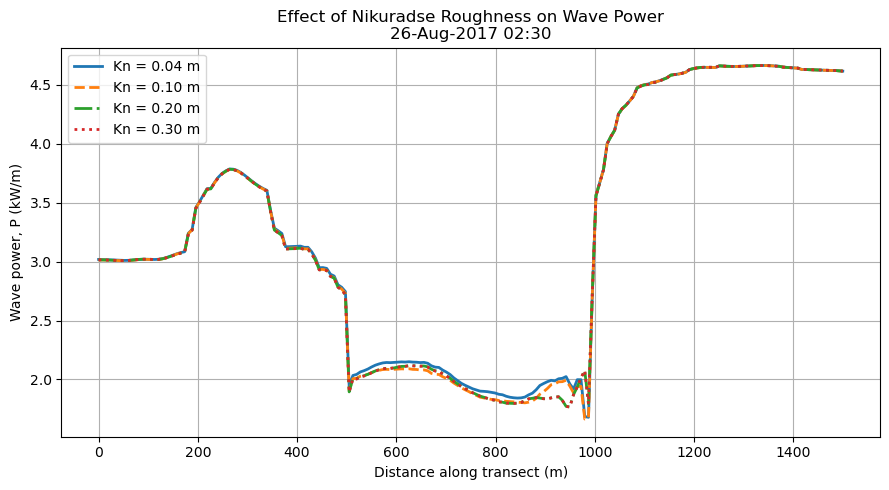

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v2.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v2.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


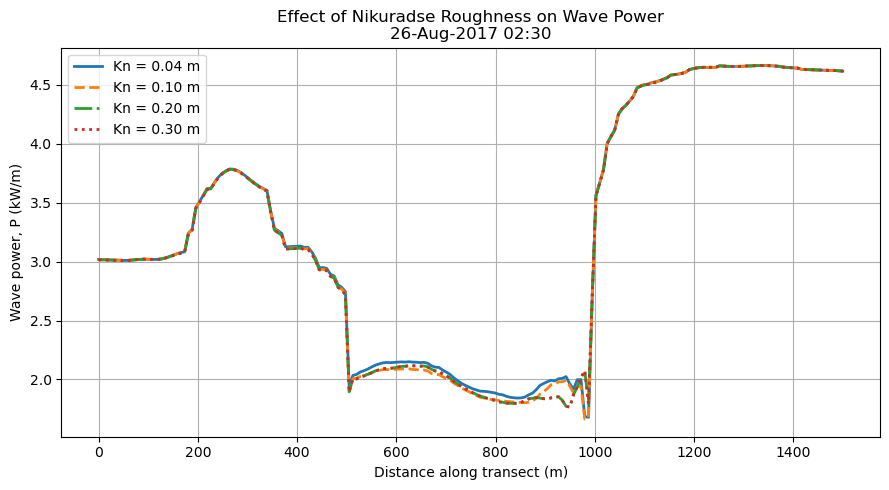

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v3.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v3.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v3.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v3.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v2.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


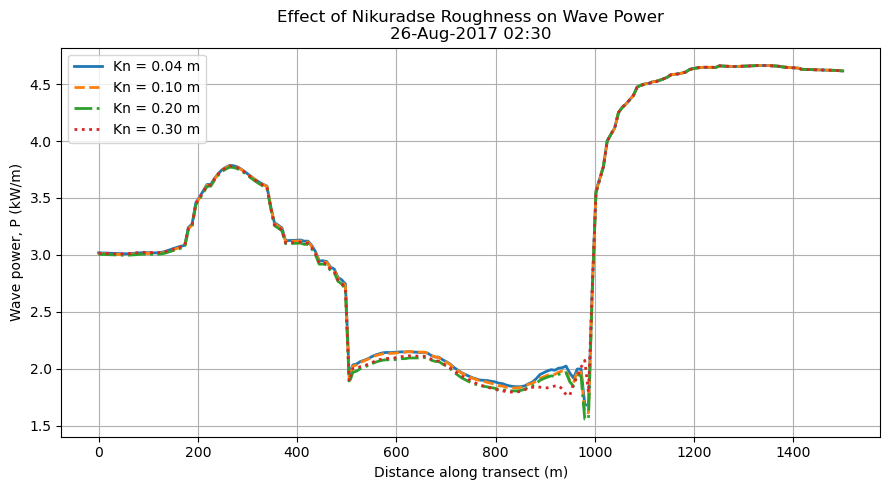

In [29]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v4.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v4.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v4.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


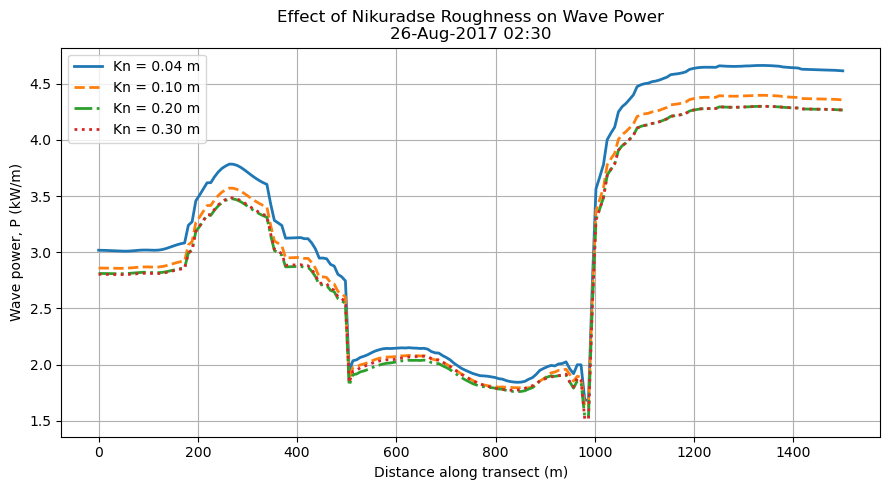

In [31]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_constant_roughness_v5.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v5.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_constant_roughness_v5.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v5.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_constant_roughness_v5.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v5.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


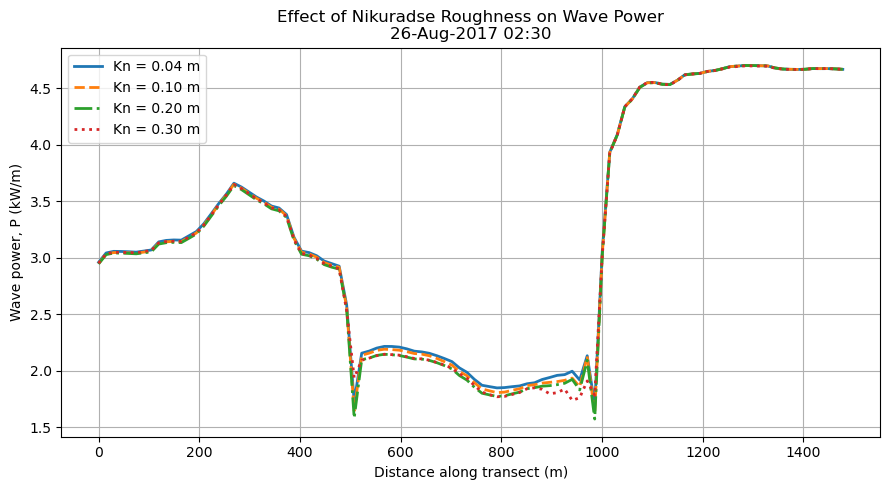

In [30]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v4.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v4.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v4.dfsu"
# Transect endpoints
x1, y1 = 730400, 3174446
x2, y2 = 731408, 3175527

# Number of sampling points
n_points = 100

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


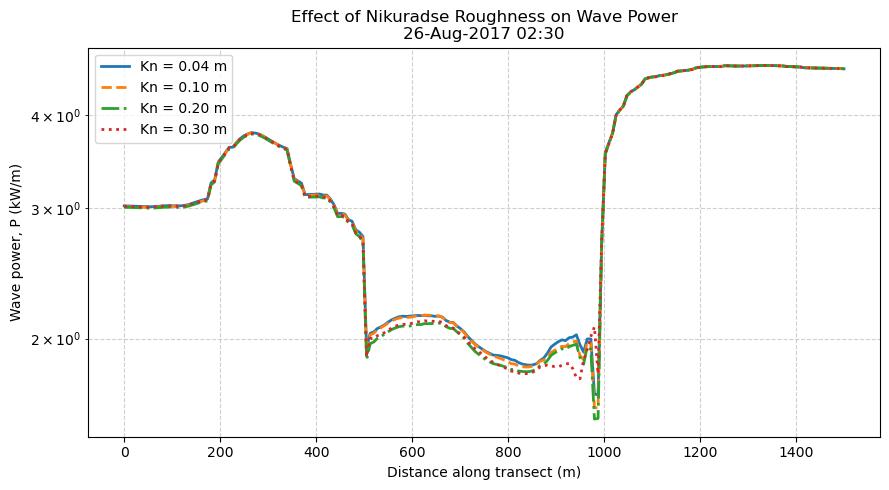

In [39]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v4.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v4.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.4m_roughness.sw - Result Files\west_side_barrier_reef_1.5m_1.5m_roughness.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Logarithmic y-axis
plt.yscale('log')

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


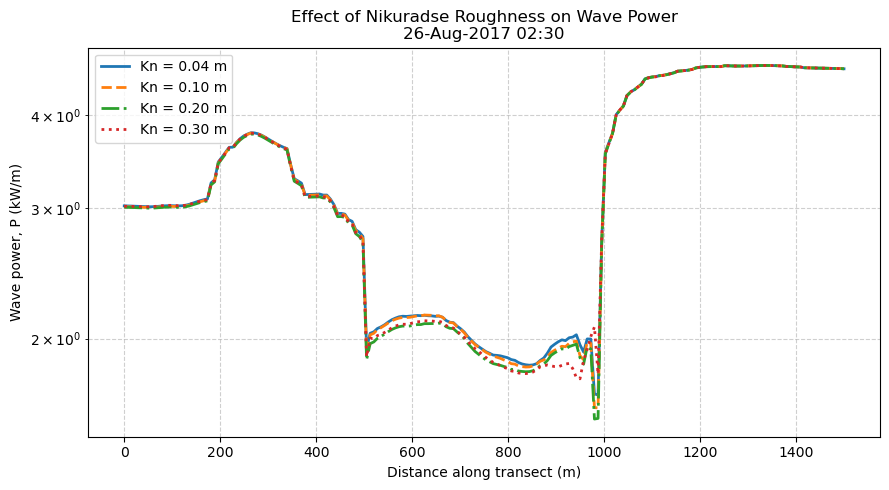

In [34]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v4.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v4.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.3m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.3m_roughness_v4.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Logarithmic y-axis
plt.yscale('log')

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Mean additional reduction (Kn=0.10): 0.37%
Mean additional reduction (Kn=0.20): 1.15%
Mean additional reduction (Kn=0.30): 0.57%


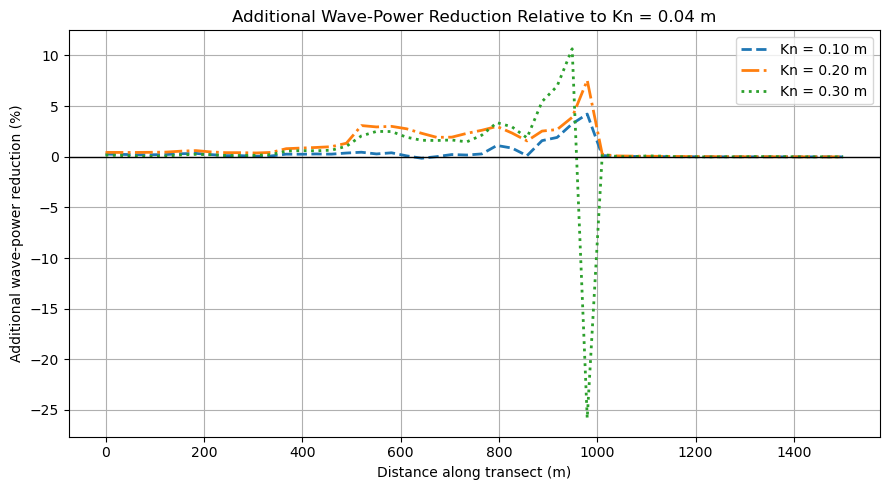

In [37]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.04m_roughness_v2.sw - Result Files\west_side_barrier_reef_1.5m_0.04m_roughness_v2.dfsu"

dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.1m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.1m_roughness_v4.dfsu"

dfsu_file_02 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.2m_roughness_v4.sw - Result Files\west_side_barrier_reef_1.5m_0.2m_roughness_v4.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_0.4m_roughness.sw - Result Files\west_side_barrier_reef_1.5m_1.5m_roughness.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

# Number of sampling points
n_points =50


# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# =========================
# Distance along transect
# =========================
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Percentage additional reduction
# Reference = Kn = 0.04 m
# =========================

# Avoid division by zero
p_ref = np.where(p_004 > 1e-6, p_004, np.nan)

reduction_01 = (p_ref - p_01) / p_ref * 100
reduction_02 = (p_ref - p_02) / p_ref * 100
reduction_03 = (p_ref - p_03) / p_ref * 100

print(f"Mean additional reduction (Kn=0.10): {np.nanmean(reduction_01):.2f}%")
print(f"Mean additional reduction (Kn=0.20): {np.nanmean(reduction_02):.2f}%")
print(f"Mean additional reduction (Kn=0.30): {np.nanmean(reduction_03):.2f}%")

# =========================
# Plot
# =========================

plt.figure(figsize=(9,5))

plt.plot(
    distance,
    reduction_01,
    linewidth=2,
    linestyle="--",
    label="Kn = 0.10 m"
)

plt.plot(
    distance,
    reduction_02,
    linewidth=2,
    linestyle="-.",
    label="Kn = 0.20 m"
)

plt.plot(
    distance,
    reduction_03,
    linewidth=2,
    linestyle=":",
    label="Kn = 0.30 m"
)

plt.axhline(
    0,
    color="k",
    linewidth=1
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Additional wave-power reduction (%)")
plt.title("Additional Wave-Power Reduction Relative to Kn = 0.04 m")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

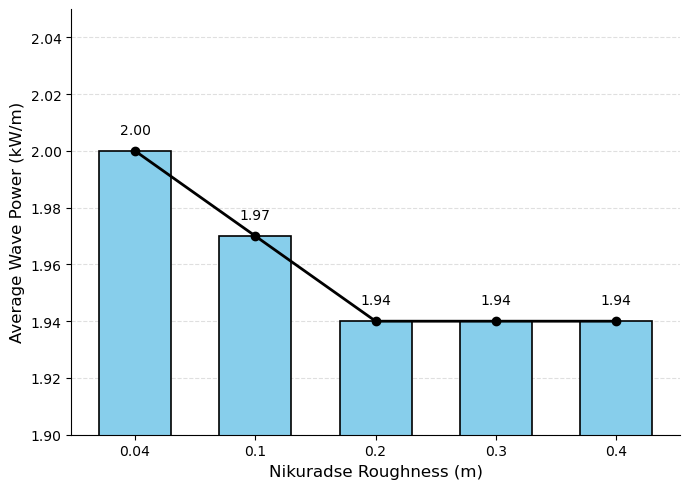

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
roughness = [0.04, 0.10, 0.20, 0.30, 0.40]
avg_wave_power = [2.00, 1.97, 1.94, 1.94, 1.94]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7,5))

# Bar chart
bars = ax.bar(
    range(len(roughness)),
    avg_wave_power,
    width=0.6,
    color='skyblue',
    edgecolor='black',
    linewidth=1.2,
    zorder=2
)

# Line connecting the bar centers
ax.plot(
    range(len(roughness)),
    avg_wave_power,
    color='black',
    marker='o',
    markersize=6,
    linewidth=2,
    zorder=3
)

# Value labels
for i, v in enumerate(avg_wave_power):
    ax.text(
        i,
        v + 0.005,
        f"{v:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Axis labels
ax.set_xlabel("Nikuradse Roughness (m)", fontsize=12)
ax.set_ylabel("Average Wave Power (kW/m)", fontsize=12)

# X-axis ticks
ax.set_xticks(range(len(roughness)))
ax.set_xticklabels([str(r) for r in roughness])

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: zoom in on small differences
ax.set_ylim(1.90, 2.05)

# Improve appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

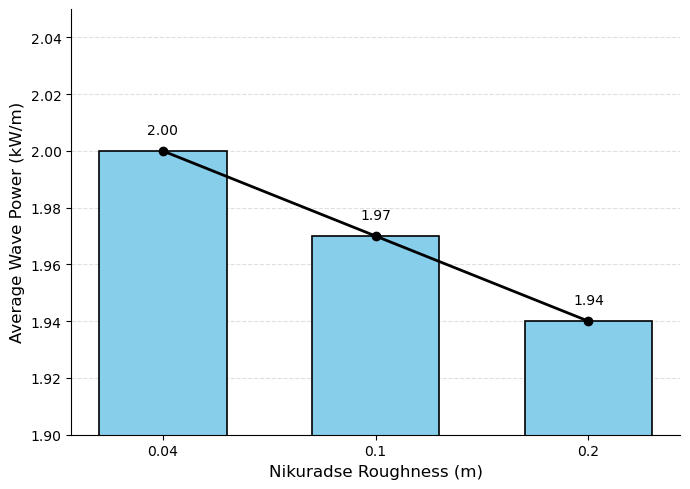

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
roughness = [0.04, 0.10, 0.20]
avg_wave_power = [2.00, 1.97, 1.94]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7,5))

# Bar chart
bars = ax.bar(
    range(len(roughness)),
    avg_wave_power,
    width=0.6,
    color='skyblue',
    edgecolor='black',
    linewidth=1.2,
    zorder=2
)

# Line connecting the bar centers
ax.plot(
    range(len(roughness)),
    avg_wave_power,
    color='black',
    marker='o',
    markersize=6,
    linewidth=2,
    zorder=3
)

# Value labels
for i, v in enumerate(avg_wave_power):
    ax.text(
        i,
        v + 0.005,
        f"{v:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Axis labels
ax.set_xlabel("Nikuradse Roughness (m)", fontsize=12)
ax.set_ylabel("Average Wave Power (kW/m)", fontsize=12)

# X-axis ticks
ax.set_xticks(range(len(roughness)))
ax.set_xticklabels([str(r) for r in roughness])

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: zoom in on small differences
ax.set_ylim(1.90, 2.05)

# Improve appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()